In [1]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10_sandbox
import numpy as np
import crocoddyl

config = UR10_sandbox
# robot_mj_model = RobotMujocoModel(config.mjcf_path, config.list_of_joints)
robot_mj_model = RobotMujocoModel("../models/ur10/ur10_sandbox_weight.xml", config.list_of_joints)
robot_pin_model = RobotPinocchioModel(config.urdf_path, config.list_of_joints)

# If using the weight model, add the payload to Pinocchio so the OCP can pre-compensate gravity.
# MPC feedback alone can partially handle small unmodeled loads (re-plans from real state each step),
# but a correct model eliminates the systematic gravity bias entirely.
payload_I = robot_mj_model.get_obj_payload("box_2")
robot_pin_model.add_payload("tool0", payload_I)

controller = RobotController(robot_pin_model)

DT = robot_mj_model.model.opt.timestep
nq = len(config.list_of_joints)
print(f"Timestep: {DT*1000:.2f} ms  |  DOF: {nq}")


Timestep: 2.00 ms  |  DOF: 6


In [4]:
path = [robot_pin_model.current_q(),
    np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
    np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
    np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
    np.array([ 0.4, -0.4, 1.5, -0.8,  1.5,  0.5])]

N_steps = 1000   # simulation steps per segment
DT_ocp = 0.01          # 10 ms per OCP step
T_mpc  = 100            # 20 × 10 ms = 0.2 s horizon
step   = int(round(DT_ocp / robot_mj_model.model.opt.timestep))  # re-plan every DT_ocp
print(f"Re-plan every {step} sim steps  |  real-time budget = {step * DT * 1000:.1f} ms")

# maxiter=100  → offline quality (slow, ~100-500 ms per solve)
# maxiter=3    → real-time capable with warm-starting (relies on good warm start)
MAXITER = 10

# SPEED = real-time factor for the mujoco viewer:
#   1.0 → real time, 2.0 → 2× faster, 0.5 → slow-motion, 0 → as fast as possible.
# If a solve overruns its budget the viewer falls behind and catches up at full speed.
SPEED = 1

import time as _time
_solve_times = []

def _timed_control(warm_xs, warm_us, x_start, x_target):
    t0 = _time.perf_counter()
    result = controller.compute_control(
        x_start, x_target,
        T=T_mpc, DT=DT_ocp,
        option="crocoddyl_advanced", solver=crocoddyl.SolverBoxFDDP,
        track_weight=3990.0,
        ctrl_weight=1080.0,
        terminal_pose_weight=21000000.0,
        v_weight=0.336,
        acc_weight=54.6,
        kp=config.kp, kd=config.kd,
        warm_xs=warm_xs, warm_us=warm_us,
        maxiter=MAXITER)
    _solve_times.append((_time.perf_counter() - t0) * 1000)
    return result

robot_mj_model.reset()

xs_mpc, us_mpc = robot_mj_model.mpc_visualize(
    path,
    compute_control=_timed_control,
    segment_lengths=[N_steps] * (len(path) - 1),
    dt=DT,
    hold=False,
    step=step,
    speed=SPEED,
    # zoh=True
)

budget_ms = step * DT * 1000
print(f"\nOCP solve times over {len(_solve_times)} solves:")
print(f"  mean  = {sum(_solve_times)/len(_solve_times):.1f} ms")
print(f"  max   = {max(_solve_times):.1f} ms")
print(f"  min   = {min(_solve_times):.1f} ms")
print(f"  budget= {budget_ms:.1f} ms  ({'OK' if max(_solve_times) < budget_ms else 'TOO SLOW for real-time'})")
print(f"\nFor real-time @ SPEED=1.0: max solve must stay < {budget_ms:.0f} ms")


Re-plan every 5 sim steps  |  real-time budget = 10.0 ms

OCP solve times over 800 solves:
  mean  = 48.4 ms
  max   = 134.3 ms
  min   = 36.0 ms
  budget= 10.0 ms  (TOO SLOW for real-time)

For real-time @ SPEED=1.0: max solve must stay < 10 ms


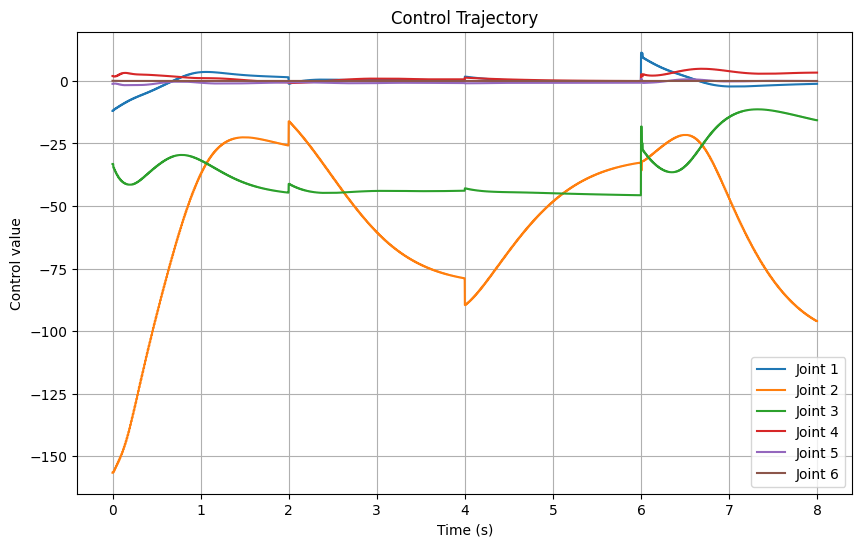

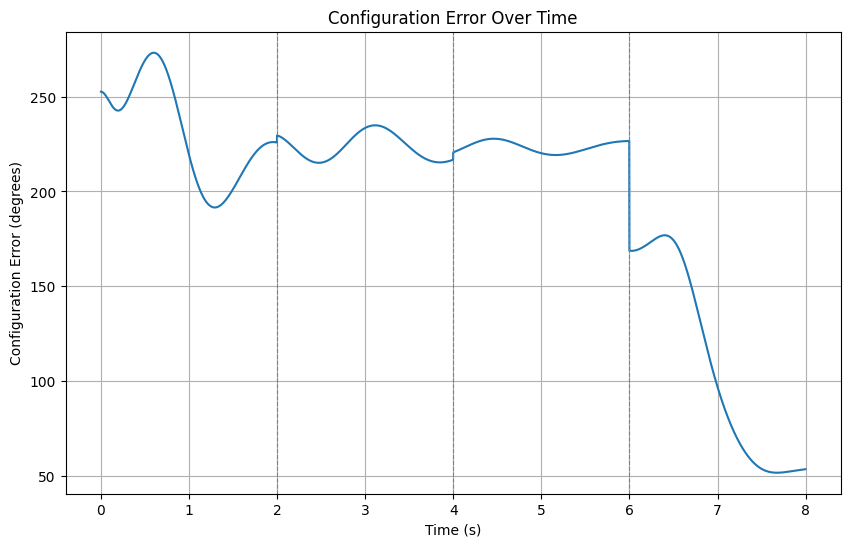

In [5]:
robot_mj_model.plot_controls(us_mpc, dt=DT)
robot_mj_model.plot_error(xs_mpc, path[1:], segment_lengths=[N_steps] * (len(path) - 1), dt=DT)


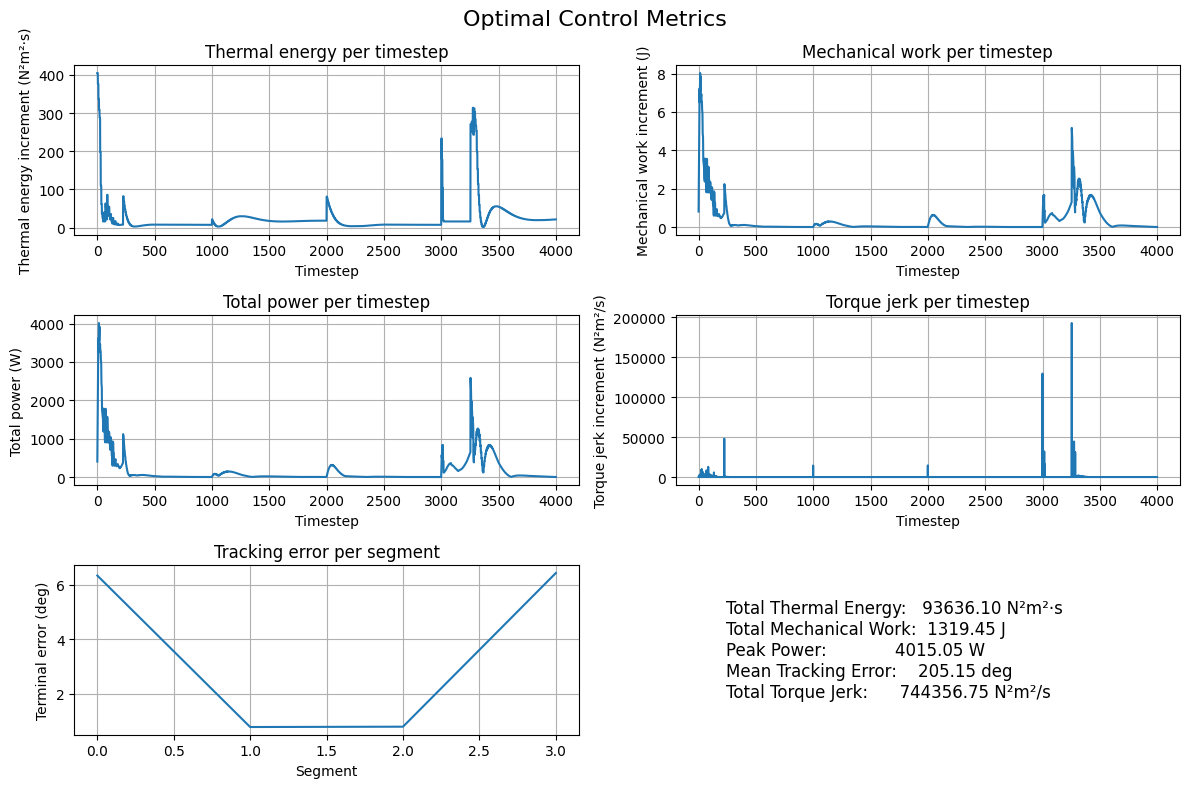

In [7]:
from optimal.metrics import plot_metrics
plot_metrics(us_mpc, xs_mpc, DT, path, segment_lengths=[N_steps] * (len(path) - 1))